In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from scipy import interpolate

In [207]:
df_Draco = pd.read_csv("/Users/lucakrattinger/Documents/MA1-EPFL/TP4/Observed-data/results_CaHK_Draco_g+dw.csv")
df_Ursa_minor = pd.read_csv("/Users/lucakrattinger/Documents/MA1-EPFL/TP4/Observed-data/results_CaHK_UrsaMinor_g+dw.csv")
df_train = pd.read_csv("/Users/lucakrattinger/Documents/MA1-EPFL/TP4/Observed-data/TrainingSample+CaHK+PS1_giants+GC+SAGA+W23.csv")


In [209]:
# Extract the useful data

# Draco
FeH_50th_Draco = df_Draco['FeH_50th'].values
g_0_Draco      = df_Draco['g_0'].values
r_0_Draco    = df_Draco['r_0'].values
CaHK_0_Draco   = df_Draco['CaHK_0'].values

# Ursa Minor

FeH_50th_UM = df_Ursa_minor['FeH_50th'].values
g_0_UM      = df_Ursa_minor['g_0'].values
r_0_UM    = df_Ursa_minor['r_0'].values
CaHK_0_UM   = df_Ursa_minor['CaHK_0'].values

# Training sample

x_train = df_train['g_0'] - df_train['r_0']
y_train = (df_train['CaHK_0'] - df_train['g_0']) - 2.4 * (df_train['g_0'] - df_train['r_0'])
feh_lit = df_train['feh_lit'] 
logg_train = df_train['logg_lit']
temp_train = df_train['teff_lit']
survey_train = df_train['survey_neverempty']

In [185]:
x_obs_Draco = g_0_Draco - r_0_Draco
y_obs_Draco = CaHK_0_Draco - g_0_Draco - 2.4*(g_0_Draco - r_0_Draco)

x_obs_UM = g_0_UM - r_0_UM
y_obs_UM = CaHK_0_UM - g_0_UM - 2.4*(g_0_UM - r_0_UM)


In [210]:
# Load the useful parameters
df = pd.read_parquet('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/code/calculated_magnitudes.parquet')

feh_list = df['feh'].tolist()
logg_list = df['logg'].tolist()
alpha_list = df['alpha'].tolist()
teff_list = df['teff'].tolist()

feh = np.array(feh_list)
logg = np.array(logg_list)
alpha = np.array(alpha_list)
teff = np.array(teff_list)

gi_listP = df['giP'].tolist()
gr_listP = df['grP'].tolist()
CaHKg_listP = df['CaHKgP'].tolist()

gi = np.array(gi_listP)
gr = np.array(gr_listP)
CaHKg = np.array(CaHKg_listP)

# Useful dataframe
df_new = pd.DataFrame({
    'metallicity': feh,
    'logg': logg,
    'Teff': teff,
    'alpha': alpha,
    'g_minus_r': gr,
    'g_minus_i': gi,
    'CaHK_minus_g' : CaHKg_listP
})

In [212]:
# Load the calibration plan
data = np.load('calibration_grids.npz')

# Extract the arrays
xx_ms, yy_ms, zz_ms = data['xx_ms'], data['yy_ms'], data['zz_ms']
xx_rg, yy_rg, zz_rg = data['xx_rg'], data['yy_rg'], data['zz_rg']

In [213]:
# Define RG mask
mask = (logg_train < 2.5) & (temp_train < 5700) & (feh_lit <=-1)

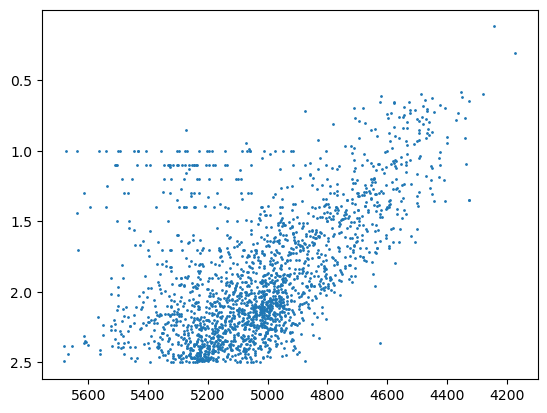

In [ ]:
# Plot the log g vs temperature from the traning sample to vizualise
plt.scatter(temp_train[mask],logg_train[mask],s=1)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

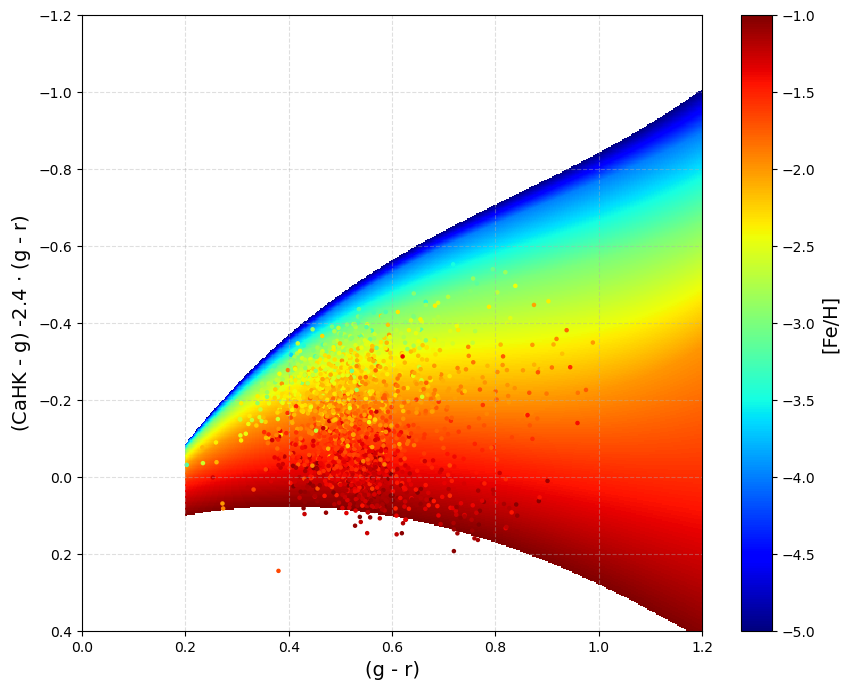

In [217]:
# Overlay calibration plan and training data
plt.figure(figsize=(10, 8))
vmin,vmax = -5,-1
cmap = plt.get_cmap('jet')
norm = plt.Normalize(vmin,vmax)
plt.pcolormesh(xx_rg, yy_rg+0.075, zz_rg, cmap=cmap, norm=norm, shading='auto')
cbar = plt.colorbar()
cbar.set_label(label='[Fe/H]', fontsize=14)
plt.xlabel('(g - r)',fontsize=14)
plt.ylabel(r'(CaHK - g) -2.4 $\cdot$ (g - r)',fontsize=14)
plt.gca().invert_yaxis()
plt.xlim(0,1.2)
plt.ylim(0.4,-1.2)
plt.grid(True, linestyle='--', alpha=0.4)

# Plot training sample 
sc = plt.scatter(x_train[mask], y_train[mask], c=feh_lit[mask], cmap=cmap, norm=norm, s=5, label='Training Stars')
plt.savefig('training.png', format='png', bbox_inches='tight')
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_32943/3673980275.py:30: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta$ [Fe/H] (Specto - Photo)',fontsize=14)
/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_32943/3673980275.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


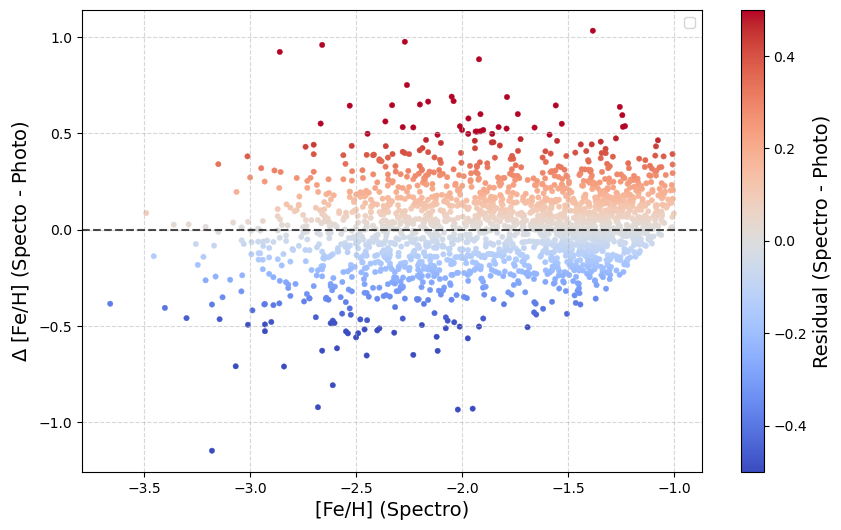

Mean Error: 0.012 dex
Median Error: 0.015 dex
Scatter (Std Dev): 0.213 dex


In [215]:
from scipy.interpolate import RegularGridInterpolator

# Setup the "Probe" 
x_axis = xx_rg[0, :]             # The unique x-coordinates
y_axis = yy_rg[:, 0] + 0.075      # The unique y-coordinates (shifted)

# Create the function that can read the smooth map at any point
probe_map = RegularGridInterpolator((y_axis, x_axis), zz_rg, bounds_error=False, fill_value=np.nan)

# Probe the map at the exact star locations
# Get coordinates of the stars
star_coords = np.column_stack((y_train[mask], x_train[mask]))

# Read the metallicity from the smooth map at these coordinates
feh_from_map = probe_map(star_coords)

# Calculate the difference
diff = feh_lit[mask] - feh_from_map

# Plot residual against the spectroscopic metallicity
plt.figure(figsize=(10, 6))
#sc = plt.scatter(feh_lit[mask], diff, c=logg_train[mask], cmap='jet', s=15, linewidth=0.3)
#sc = plt.scatter(feh_lit[mask], diff, c=temp_train[mask], cmap='jet', s=15, linewidth=0.3)
sc = plt.scatter(feh_lit[mask], diff, c=diff, cmap='coolwarm', vmin=-0.5, vmax=0.5, s=15, linewidth=0.3)

plt.axhline(0, color='black', linestyle='--', alpha=0.7) # Line of no difference
cbar = plt.colorbar(sc)
cbar.set_label(label='Residual (Spectro - Photo)',fontsize=14)
plt.xlabel('[Fe/H] (Spectro)',fontsize=14)
plt.ylabel('$\Delta$ [Fe/H] (Specto - Photo)',fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.savefig('diffmet.svg', format='svg', bbox_inches='tight')

plt.show()

# Print statistics
print(f"Mean Error: {np.nanmean(diff):.3f} dex")
print(f"Median Error: {np.nanmedian(diff):.3f} dex")
print(f"Scatter (Std Dev): {np.nanstd(diff):.3f} dex")